# Support Vector Machine (SVM) - Handwritten Digit Classification

## Objective
- Classify handwritten digits using SVM.
- Use first 1000 samples from the Digits dataset.
- Compare Linear Kernel and RBF Kernel.
- Measure training time.
- Evaluate accuracy.
- Visualize confusion matrix.
- Plot decision boundary for digits 0 and 1 using PCA.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

In [3]:
digits = load_digits()

X = digits.data
y = digits.target

print("Original Dataset Shape:", X.shape)

Original Dataset Shape: (1797, 64)


In [4]:
X = X[:1000]
y = y[:1000]

print("Dataset Shape After Selecting First 1000 Samples:", X.shape)

Dataset Shape After Selecting First 1000 Samples: (1000, 64)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 800
Testing Samples : 200


In [6]:
start_time = time.time()

linear_svm = SVC(kernel='linear')

linear_svm.fit(X_train, y_train)

linear_training_time = time.time() - start_time

linear_predictions = linear_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test, linear_predictions)

print("Linear Kernel SVM")
print("Training Time:", round(linear_training_time, 4), "seconds")
print("Accuracy:", round(linear_accuracy * 100, 2), "%")

Linear Kernel SVM
Training Time: 0.0454 seconds
Accuracy: 98.5 %


In [7]:
start_time = time.time()

rbf_svm = SVC(kernel='rbf')

rbf_svm.fit(X_train, y_train)

rbf_training_time = time.time() - start_time

rbf_predictions = rbf_svm.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_predictions)

print("RBF Kernel SVM")
print("Training Time:", round(rbf_training_time, 4), "seconds")
print("Accuracy:", round(rbf_accuracy * 100, 2), "%")

RBF Kernel SVM
Training Time: 0.0363 seconds
Accuracy: 99.5 %


In [8]:
print("========== Comparison ==========")

print("Linear Kernel Accuracy :", round(linear_accuracy * 100, 2), "%")
print("RBF Kernel Accuracy    :", round(rbf_accuracy * 100, 2), "%")

print("Linear Training Time   :", round(linear_training_time, 4), "sec")
print("RBF Training Time      :", round(rbf_training_time, 4), "sec")

========== Comparison ==========
Linear Kernel Accuracy : 98.5 %
RBF Kernel Accuracy    : 99.5 %
Linear Training Time   : 0.0454 sec
RBF Training Time      : 0.0363 sec


In [9]:
print(classification_report(y_test, rbf_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.97        18
           5       1.00      0.96      0.98        23
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        17
           8       1.00      1.00      1.00        19
           9       1.00      1.00      1.00        20

    accuracy                           0.99       200
   macro avg       0.99      1.00      1.00       200
weighted avg       1.00      0.99      1.00       200



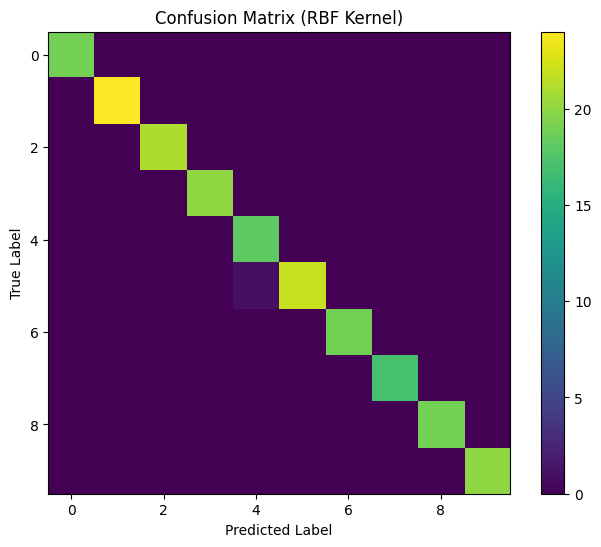

In [10]:
cm = confusion_matrix(y_test, rbf_predictions)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix (RBF Kernel)")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Create Two-Class Dataset

Select only digits 0 and 1 for decision boundary visualization.

In [11]:
mask = (y == 0) | (y == 1)

X_binary = X[mask]
y_binary = y[mask]

print("Binary Dataset Shape:", X_binary.shape)

Binary Dataset Shape: (201, 64)


# Apply PCA

Reduce dimensions from 64 features to 2 features for visualization.

In [12]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_binary)

print("Shape After PCA:", X_pca.shape)

Shape After PCA: (201, 2)


# Train RBF SVM on PCA Data

In [13]:
svm_2d = SVC(kernel='rbf')

svm_2d.fit(X_pca, y_binary)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# Create Mesh Grid for Decision Boundary

In [14]:
h = 0.02

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

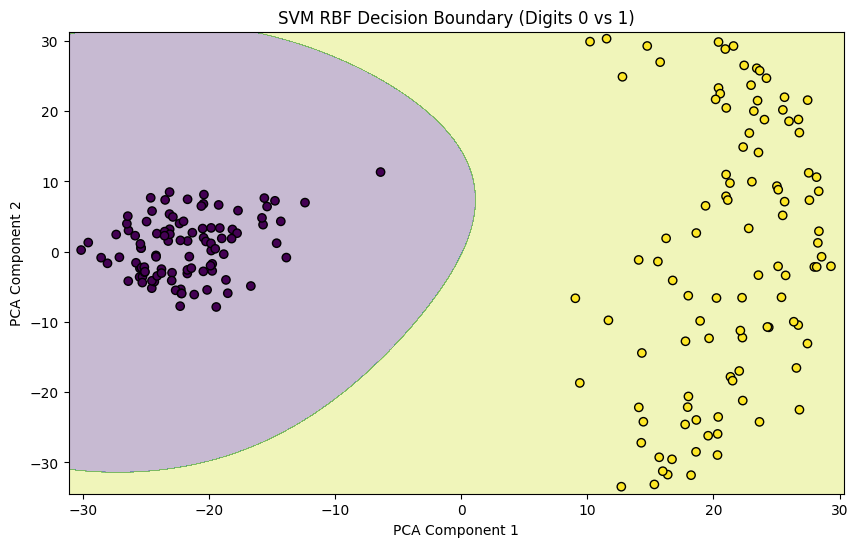

In [15]:
plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_binary,
    edgecolors='k'
)

plt.title("SVM RBF Decision Boundary (Digits 0 vs 1)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()